# Human Activity Recognition

Zbiór przedstawia badania nad rozpoznawalnością aktywności ludzkiej za pomocą przyśpieszeniomierza i żyroskopu z smartfona. Wybrano grupę 30 uczestników.
Uczestnicy wykonywali sześć czynności: stanie, chodzenie, leżenie, siedzenie, wchodzenie po schodach i schodzenie po schodach, z przymocowanym smartfonem Samsung Galaxy SII do nadgarstka.
Mierzono przyśpieszenie i prędkość kątową poprzez przyspieszeniomierz i żyroskop z smartfonu.
Sygnały czasowe próbkowano w oknach 2,56 sekundowych i nakładających się na siebie o 50%.
Baza danych zawiera 561 atrybutów do opisania każdego „okienka czasowego”.

Baza danych:
https://archive.ics.uci.edu/ml/datasets/human+activity+recognition+using+smartphones`

## Przygotowanie Danych

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [92]:
train_df = pd.read_csv('./X_train.txt', header=None, delimiter=r'\s+')

In [93]:
y_train = pd.read_csv('./y_train.txt', header=None, delimiter=r'\s+')

In [94]:
test_df = pd.read_csv('./X_test.txt', header=None, delimiter=r"\s+")

In [95]:
y_test = pd.read_csv('./y_test.txt', header=None, delimiter=r'\s+')

In [96]:
features_df = pd.read_csv('./features.txt',delimiter=r"\s+",header=None)
features_df.loc[-1] = 'activity'

In [97]:
variable_names = features_df[1].to_list()

In [98]:
train_df['activity'] = y_train
train_df.columns = variable_names

In [99]:
test_df['activity'] = y_test
test_df.columns = variable_names

## Opis zbioru

Każde okienko czasowe to jeden rekord, w zbiorze treningowym jest ich 7352, a w  testowym 2947.

In [100]:
train_df

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,5
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,5
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,5
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,5
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7347,0.299665,-0.057193,-0.181233,-0.195387,0.039905,0.077078,-0.282301,0.043616,0.060410,0.210795,...,-0.588433,-0.880324,-0.190437,0.829718,0.206972,-0.425619,-0.791883,0.238604,0.049819,2
7348,0.273853,-0.007749,-0.147468,-0.235309,0.004816,0.059280,-0.322552,-0.029456,0.080585,0.117440,...,-0.390738,-0.680744,0.064907,0.875679,-0.879033,0.400219,-0.771840,0.252676,0.050053,2
7349,0.273387,-0.017011,-0.045022,-0.218218,-0.103822,0.274533,-0.304515,-0.098913,0.332584,0.043999,...,0.025145,-0.304029,0.052806,-0.266724,0.864404,0.701169,-0.779133,0.249145,0.040811,2
7350,0.289654,-0.018843,-0.158281,-0.219139,-0.111412,0.268893,-0.310487,-0.068200,0.319473,0.101702,...,0.063907,-0.344314,-0.101360,0.700740,0.936674,-0.589479,-0.785181,0.246432,0.025339,2


In [101]:
test_df

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",activity
0,0.257178,-0.023285,-0.014654,-0.938404,-0.920091,-0.667683,-0.952501,-0.925249,-0.674302,-0.894088,...,-0.330370,-0.705974,0.006462,0.162920,-0.825886,0.271151,-0.720009,0.276801,-0.057978,5
1,0.286027,-0.013163,-0.119083,-0.975415,-0.967458,-0.944958,-0.986799,-0.968401,-0.945823,-0.894088,...,-0.121845,-0.594944,-0.083495,0.017500,-0.434375,0.920593,-0.698091,0.281343,-0.083898,5
2,0.275485,-0.026050,-0.118152,-0.993819,-0.969926,-0.962748,-0.994403,-0.970735,-0.963483,-0.939260,...,-0.190422,-0.640736,-0.034956,0.202302,0.064103,0.145068,-0.702771,0.280083,-0.079346,5
3,0.270298,-0.032614,-0.117520,-0.994743,-0.973268,-0.967091,-0.995274,-0.974471,-0.968897,-0.938610,...,-0.344418,-0.736124,-0.017067,0.154438,0.340134,0.296407,-0.698954,0.284114,-0.077108,5
4,0.274833,-0.027848,-0.129527,-0.993852,-0.967445,-0.978295,-0.994111,-0.965953,-0.977346,-0.938610,...,-0.534685,-0.846595,-0.002223,-0.040046,0.736715,-0.118545,-0.692245,0.290722,-0.073857,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2942,0.310155,-0.053391,-0.099109,-0.287866,-0.140589,-0.215088,-0.356083,-0.148775,-0.232057,0.185361,...,-0.376278,-0.750809,-0.337422,0.346295,0.884904,-0.698885,-0.651732,0.274627,0.184784,2
2943,0.363385,-0.039214,-0.105915,-0.305388,0.028148,-0.196373,-0.373540,-0.030036,-0.270237,0.185361,...,-0.320418,-0.700274,-0.736701,-0.372889,-0.657421,0.322549,-0.655181,0.273578,0.182412,2
2944,0.349966,0.030077,-0.115788,-0.329638,-0.042143,-0.250181,-0.388017,-0.133257,-0.347029,0.007471,...,-0.118854,-0.467179,-0.181560,0.088574,0.696663,0.363139,-0.655357,0.274479,0.181184,2
2945,0.237594,0.018467,-0.096499,-0.323114,-0.229775,-0.207574,-0.392380,-0.279610,-0.289477,0.007471,...,-0.205445,-0.617737,0.444558,-0.819188,0.929294,-0.008398,-0.659719,0.264782,0.187563,2


Posiadamy trzy sygnały wyrażone wektorami XYZ:
- BodyAcc - przyśpieszenie telefonu
- GravityAcc - przyśpieszenie grawitacyjne
- BodyGyro - przyśpieszenie kątowe telefonu
Z każdego sygnału obliczono zryw (zmiana przyśpieszenia w czasie), później magnitudę. Później podwojono każdą kolumnę, dla kopi zastosowano szybką tranformację fouriera. Wreszcie, dla każdej kolumny obliczono: podstawowe dane statystyczne.
Ostatecznie otrzymaliśmy 561 kolumn, wszystkie to typ float. Ostatnia kolumna to oznaczenie danej aktywności:
- 1 chodzenie
- 2 wchodzenie po schodach
- 3 schodzenie po schodach
- 4 siedzenie
- 5 stanie
- 6 leżenie
Ilość kolumn może sprawiać problem

Upewnijmy się że nie ma wartości null

In [102]:
train_df.isna().sum().sum()

np.int64(0)

In [103]:
test_df.isna().sum().sum()

np.int64(0)

## Wybór znaczących atrybutów

Jak wiemy, nie każdy atrybut będzie ważny, sprawdźmy najpierw które atrybuty korelują z każdą z aktywności

In [104]:
train_dummies = pd.get_dummies(train_df, columns = ['activity'])
train_dummies

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,"angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",activity_1,activity_2,activity_3,activity_4,activity_5,activity_6
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.018446,-0.841247,0.179941,-0.058627,False,False,False,False,True,False
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.703511,-0.844788,0.180289,-0.054317,False,False,False,False,True,False
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.808529,-0.848933,0.180637,-0.049118,False,False,False,False,True,False
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.485366,-0.848649,0.181935,-0.047663,False,False,False,False,True,False
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.615971,-0.847865,0.185151,-0.043892,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7347,0.299665,-0.057193,-0.181233,-0.195387,0.039905,0.077078,-0.282301,0.043616,0.060410,0.210795,...,-0.425619,-0.791883,0.238604,0.049819,False,True,False,False,False,False
7348,0.273853,-0.007749,-0.147468,-0.235309,0.004816,0.059280,-0.322552,-0.029456,0.080585,0.117440,...,0.400219,-0.771840,0.252676,0.050053,False,True,False,False,False,False
7349,0.273387,-0.017011,-0.045022,-0.218218,-0.103822,0.274533,-0.304515,-0.098913,0.332584,0.043999,...,0.701169,-0.779133,0.249145,0.040811,False,True,False,False,False,False
7350,0.289654,-0.018843,-0.158281,-0.219139,-0.111412,0.268893,-0.310487,-0.068200,0.319473,0.101702,...,-0.589479,-0.785181,0.246432,0.025339,False,True,False,False,False,False


In [105]:
correlations = train_dummies.corrwith(train_dummies['activity_1'])
for i in range(2, 7):
  new_cor = train_dummies.corrwith(train_dummies[f'activity_{i}'])

In [106]:
correlations_df = pd.DataFrame(train_dummies.corrwith(train_dummies['activity_1']), columns=['activity_1'])

for i in range(2, 7):
  new_cor = train_dummies.corrwith(train_dummies[f'activity_{i}'])
  correlations_df[f'activity_{i}'] = new_cor
correlations_df = correlations_df.drop([f'activity_{i}' for i in range(1, 7)], axis='rows')
correlations_df

,activity_1,activity_2,activity_3,activity_4,activity_5,activity_6
tBodyAcc-mean()-X,0.011284,-0.073894,0.076635,-0.006810,0.032793,-0.036680
tBodyAcc-mean()-Y,-0.000792,-0.090680,0.012781,0.062653,0.018472,-0.007747
tBodyAcc-mean()-Z,0.002030,-0.082358,0.022799,0.020816,0.015335,0.016943
tBodyAcc-std()-X,0.291920,0.354111,0.653684,-0.387895,-0.405914,-0.383848
tBodyAcc-std()-Y,0.436728,0.419947,0.462078,-0.389586,-0.405462,-0.412984
...,...,...,...,...,...,...
"angle(tBodyGyroMean,gravityMean)",-0.004083,-0.112629,0.113900,0.006045,-0.005282,0.005680
"angle(tBodyGyroJerkMean,gravityMean)",-0.008567,0.043900,-0.053146,-0.021184,0.018823,0.016562
"angle(X,gravityMean)",-0.233903,-0.116118,-0.222029,-0.181082,-0.266279,0.956927
"angle(Y,gravityMean)",0.243434,0.310982,0.186124,-0.096667,0.241314,-0.816776


Zostawmy tylko znaczące korelacje

In [107]:
min_corr = 0.7
corr_filtered = correlations_df[(correlations_df['activity_1'].abs() >= min_corr) | (correlations_df['activity_2'].abs() >= min_corr)
| (correlations_df['activity_3'].abs() >= min_corr) | (correlations_df['activity_4'].abs() >= min_corr) | (correlations_df['activity_5'].abs() >= min_corr)
 | (correlations_df['activity_6'].abs() >= min_corr)]
corr_filtered

,activity_1,activity_2,activity_3,activity_4,activity_5,activity_6
tBodyAcc-energy()-X,0.117973,0.219365,0.752507,-0.317275,-0.331411,-0.325724
tGravityAcc-mean()-X,0.233057,0.166606,0.198187,0.184252,0.256753,-0.974406
tGravityAcc-mean()-Y,-0.253028,-0.330877,-0.188314,0.138274,-0.248802,0.812860
tGravityAcc-max()-X,0.230519,0.173270,0.204391,0.180034,0.249624,-0.972219
tGravityAcc-max()-Y,-0.258274,-0.321560,-0.183894,0.136029,-0.257128,0.816059
tGravityAcc-min()-X,0.234820,0.159741,0.192409,0.187055,0.262354,-0.973167
tGravityAcc-min()-Y,-0.246052,-0.336144,-0.193150,0.136807,-0.239916,0.807776
tGravityAcc-energy()-X,0.247204,0.138965,0.204376,0.162340,0.278103,-0.968362
tGravityAcc-energy()-Y,-0.197570,-0.104696,-0.189768,-0.171980,-0.217076,0.826755
tGravityAcc-energy()-Z,-0.198741,-0.121163,-0.176190,-0.114248,-0.221264,0.779279


In [108]:
used_atr = list(corr_filtered.index)

## Zbiór walidacyjny

Teraz podzielmy testowy dataframe na test i validation

In [109]:
shuffle_df = test_df.sample(frac=1)
validation_df, test_df = shuffle_df.iloc[:1474], shuffle_df.iloc[1474:]
validation_df

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",activity
806,0.281490,-0.008147,-0.065483,-0.945191,-0.918188,-0.839197,-0.966552,-0.932220,-0.869464,-0.839436,...,0.373036,0.079984,0.049839,-0.149094,0.068895,-0.223469,-0.867085,0.086726,0.114801,4
1475,0.385822,-0.004999,-0.100548,0.135288,0.198820,-0.534498,0.036099,0.216195,-0.570194,0.508292,...,-0.260990,-0.618340,-0.695984,0.458857,0.839576,-0.052032,-0.816009,0.225179,0.024249,3
1334,0.198864,-0.010817,-0.100608,-0.016061,-0.300276,-0.421728,-0.100163,-0.351057,-0.453677,0.340516,...,-0.434817,-0.759584,0.950934,-0.869973,-0.945248,-0.003338,-0.838177,0.198275,0.069801,3
987,0.336114,-0.008051,-0.101073,-0.124710,0.095159,-0.413540,-0.196973,0.091245,-0.362042,0.222926,...,-0.192649,-0.585239,-0.623414,-0.292571,-0.866944,-0.828195,-0.798703,0.235119,-0.007386,1
1496,0.233013,0.002288,-0.074162,-0.150676,-0.184824,-0.403926,-0.250567,-0.172667,-0.385609,0.259355,...,-0.584096,-0.882580,0.474991,-0.765596,0.953626,-0.328027,-0.748062,0.269802,0.047522,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308,0.265173,-0.010027,-0.077670,-0.979253,-0.850625,-0.902779,-0.981926,-0.846699,-0.900691,-0.922875,...,-0.454048,-0.789756,0.037132,0.135580,-0.889079,0.763058,-0.782736,0.127582,-0.136697,5
1800,0.288717,-0.022060,-0.092009,-0.371850,0.205228,-0.411859,-0.434948,0.128024,-0.384601,-0.049755,...,0.135377,-0.173603,-0.316344,0.239978,0.378916,-0.537225,-0.713396,0.295043,-0.003574,1
1582,0.266220,-0.022378,-0.099406,-0.975840,-0.944163,-0.965717,-0.975558,-0.939294,-0.962303,-0.926618,...,0.158488,-0.194688,-0.123542,0.174678,0.104542,-0.233271,0.342408,-0.190827,-0.773006,6
1139,0.345242,-0.017785,-0.051338,-0.078009,-0.057324,-0.202110,-0.134590,-0.171758,-0.208367,0.100948,...,-0.532131,-0.881719,-0.439698,0.349098,0.776687,0.984118,-0.911913,0.050013,-0.026301,1


## SOM

Wyznaczmy jakieś wartości początkowe

In [110]:
pip install MiniSom

In [111]:
from minisom import MiniSom

In [112]:
learning = 0.1
epochs = 200
sigma = 5

Obliczmy rozmiar mapy

In [113]:
from math import sqrt
dim = round(sqrt(sqrt(len(train_df)) * 5))
dim

21

In [114]:
used_df = train_df[used_atr]
used_df

,tBodyAcc-energy()-X,tGravityAcc-mean()-X,tGravityAcc-mean()-Y,tGravityAcc-max()-X,tGravityAcc-max()-Y,tGravityAcc-min()-X,tGravityAcc-min()-Y,tGravityAcc-energy()-X,tGravityAcc-energy()-Y,tGravityAcc-energy()-Z,...,"fBodyAcc-bandsEnergy()-1,24","fBodyAccJerk-bandsEnergy()-1,8","fBodyAccJerk-bandsEnergy()-1,8","fBodyAccJerk-bandsEnergy()-1,8","fBodyAccJerk-bandsEnergy()-1,16","fBodyAccJerk-bandsEnergy()-1,16","fBodyAccJerk-bandsEnergy()-1,16",fBodyAccMag-energy(),"angle(X,gravityMean)","angle(Y,gravityMean)"
0,-0.999945,0.963396,-0.140840,0.892055,-0.161265,0.977436,-0.123213,0.899469,-0.970905,-0.975510,...,-0.994877,-0.999986,-0.999933,-0.999400,-0.999982,-0.999900,-0.999620,-0.998285,-0.841247,0.179941
1,-0.999991,0.966561,-0.141551,0.892060,-0.161343,0.984520,-0.114893,0.907829,-0.970583,-0.978500,...,-0.998553,-0.999996,-0.999861,-0.999859,-0.999987,-0.999817,-0.999852,-0.999472,-0.844788,0.180289
2,-0.999969,0.966878,-0.142010,0.892401,-0.163711,0.986770,-0.114893,0.908668,-0.970368,-0.981672,...,-0.999434,-0.999994,-0.999820,-0.999871,-0.999963,-0.999732,-0.999803,-0.999807,-0.848933,0.180637
3,-0.999976,0.967615,-0.143976,0.893817,-0.163711,0.986821,-0.121336,0.910621,-0.969400,-0.982420,...,-0.999792,-0.999998,-0.999895,-0.999885,-0.999978,-0.999798,-0.999756,-0.999770,-0.848649,0.181935
4,-0.999991,0.968224,-0.148750,0.893817,-0.166786,0.987434,-0.121834,0.912235,-0.967051,-0.984363,...,-0.999812,-0.999995,-0.999925,-0.999845,-0.999988,-0.999878,-0.999853,-0.999873,-0.847865,0.185151
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7347,-0.674986,0.923148,-0.222004,0.867718,-0.214233,0.920554,-0.234998,0.794766,-0.918375,-0.995193,...,-0.403800,-0.839256,-0.684532,-0.714479,-0.775736,-0.839183,-0.828551,-0.584282,-0.791883,0.238604
7348,-0.706359,0.918343,-0.242054,0.866116,-0.231477,0.920554,-0.234998,0.782407,-0.902880,-0.995151,...,-0.421114,-0.854278,-0.715969,-0.725265,-0.780751,-0.843252,-0.798232,-0.632536,-0.771840,0.252676
7349,-0.693162,0.919810,-0.236950,0.854641,-0.249134,0.933008,-0.216004,0.786085,-0.907561,-0.995450,...,-0.165022,-0.815380,-0.664626,-0.658937,-0.783616,-0.840560,-0.801553,-0.641170,-0.779133,0.249145
7350,-0.693855,0.922323,-0.233230,0.855988,-0.244267,0.933008,-0.210542,0.792538,-0.910648,-0.998824,...,-0.173110,-0.822905,-0.689422,-0.652902,-0.821137,-0.822665,-0.822642,-0.663579,-0.785181,0.246432


In [115]:
train_array = used_df.values
som = MiniSom(x=dim, y=dim, input_len=train_array.shape[1], sigma=sigma, learning_rate=learning)
som.train_random(train_array, epochs)

In [116]:
val_used = validation_df[used_atr]
validation_arr = val_used.values
print(f"Quantization Error: {som.quantization_error(validation_arr)}")

Quantization Error: 0.7941677811333715


Stwórzmy U - Matrix


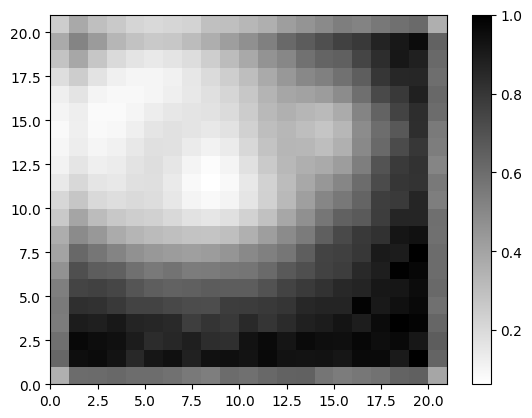

In [117]:
plt.pcolor(som.distance_map().T, cmap='gist_yarg')
plt.colorbar()
plt.show()

## Walidacja

In [123]:
# skrócenie przygotowania modelu
def test_model(correlations_df, min_corr, learning, iters, sigma, train_df, validation_df):
  corr_filtered = correlations_df[(correlations_df['activity_1'].abs() >= min_corr) | (correlations_df['activity_2'].abs() >= min_corr)
  | (correlations_df['activity_3'].abs() >= min_corr) | (correlations_df['activity_4'].abs() >= min_corr) | (correlations_df['activity_5'].abs() >= min_corr)
  | (correlations_df['activity_6'].abs() >= min_corr)]
  used_atr = list(corr_filtered.index)
  dim = round(sqrt(sqrt(len(train_df)) * 5))
  used_df = train_df[used_atr]
  train_array = used_df.values
  som = MiniSom(x=dim, y=dim, input_len=train_array.shape[1], sigma=sigma, learning_rate=learning)
  som.train_random(train_array, iters)
  val_used = validation_df[used_atr]
  validation_arr = val_used.values
  return som.quantization_error(validation_arr), som.topographic_error(validation_arr)

In [119]:
def plot(quant_err, top_err, x, x_title):
  plt.plot(x, quant_err, color ='red', label='quantitive error')
  plt.plot(x, top_err, color ='blue', label='topographical error')
  plt.xlabel(x_title)
  plt.show()

### Minimalna korelacja
Zobaczmy jak model poradzi sobie dla różnych minimalnych korelacji

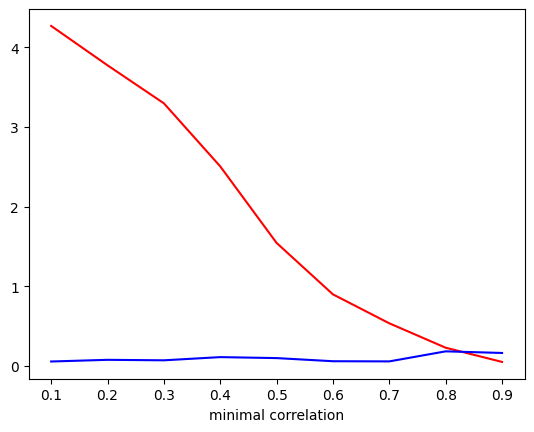

In [124]:
learning = 0.5
epochs = 200
sigma = 5
quant_err = []
top_err = []
for i in range(1, 10):
  quant, topograph = test_model(correlations_df, i/10, learning, epochs, sigma, train_df, validation_df)
  quant_err.append(quant)
  top_err.append(topograph)
plot(quant_err, top_err, [i/10 for i in range(1, 10)], "minimal correlation")

Zostańmy przy limicie dolnym 0.8

### Liczba iteracji

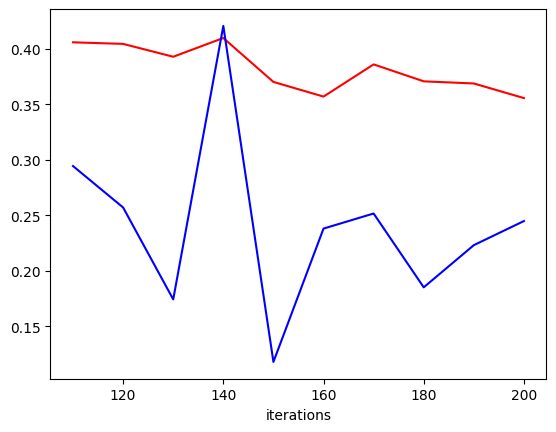

In [135]:
min_cor = 0.8
learning = 0.1
sigma = 5
quant_err = []
topograph_err = []
for i in range(1, 11):
  epochs = 100 + i * 10
  quant, topograph = test_model(correlations_df, min_cor, learning, epochs, sigma, train_df, validation_df)
  quant_err.append(quant)
  topograph_err.append(topograph)
plot(quant_err, topograph_err, [100 + i * 10 for i in range(1,11)], "iterations")

Różnice są małe, ale załóżmy że 170 to optymalna wartość

### Rozproszenie funkcji sąsiedztwa

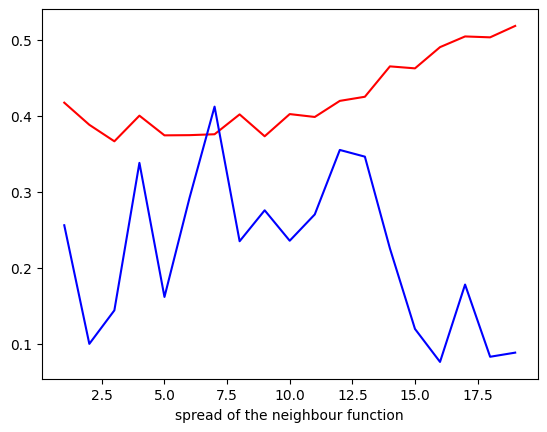

In [138]:
min_cor = 0.8
epochs = 170
learning = 0.1
quant_err = []
topograph_err = []
for i in range(1, 20):
  quant, topograph = test_model(correlations_df, min_cor, learning, epochs, i, train_df, validation_df)
  quant_err.append(quant)
  topograph_err.append(topograph)
plot(quant_err, topograph_err, range(1, 20), "spread of the neighbour function")

Jak widać najlepsza wartość to 3, chociaż różnice są małe

## Najbardziej optymalny model końcowy

In [167]:
min_cor = 0.8
epochs = 170
learning = 0.1
sigma = 3
corr_filtered = correlations_df[(correlations_df['activity_1'].abs() >= min_corr) | (correlations_df['activity_2'].abs() >= min_corr)
  | (correlations_df['activity_3'].abs() >= min_corr) | (correlations_df['activity_4'].abs() >= min_corr) | (correlations_df['activity_5'].abs() >= min_corr)
  | (correlations_df['activity_6'].abs() >= min_corr)]

used_atr = list(corr_filtered.index)
dim = round(sqrt(sqrt(len(train_df)) * 5))
used_df = train_df[used_atr]
train_array = used_df.values

som = MiniSom(x=dim, y=dim, input_len=train_array.shape[1], sigma=sigma, learning_rate=learning)
som.train_random(train_array, epochs)

test_used = test_df[used_atr]
test_arr = test_used.values

print(f"Quantization error {som.quantization_error(test_arr)}")
print(f"Topographic error {som.topographic_error(test_arr)}")

Quantization error 0.8141077294801872
Topographic error 0.07671418873048201


## U - Matrix

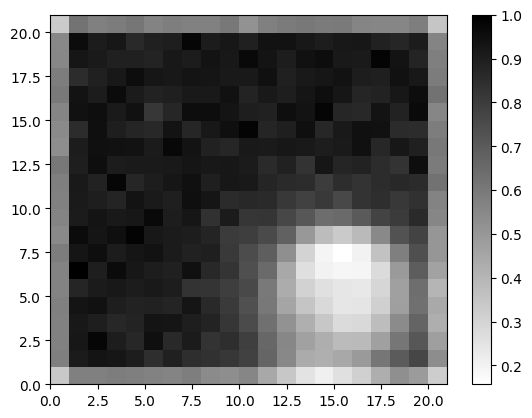

In [170]:
plt.pcolor(som.distance_map().T, cmap='gist_yarg')
plt.colorbar()
plt.show()

## Wnioski


Niski błąd topograficzny wskazuje na to że mapa dobrze odwzoruje odległości w przestrzeni wektorowej próbek. Jednak wysoki błąd kwantyzacji i mapa U Matrix pokazują że model ten nie jest dobry do rozpoznawania aktywności z tego zbioru.